In [1]:
#load packages
import numpy as np
import xarray as xr
import math
import csv

import matplotlib.pyplot as plt
%matplotlib inline

import os
import pandas as pd
import cmocean
import matplotlib.gridspec as gridspec

from scipy.stats import norm
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes

# import gsw_xarray as gsw_xr # seawater calculations - might not need this one
import gsw as gsw
## mapping packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyproj import Transformer, Geod
from shapely.geometry import LineString, Point
from scipy.signal import savgol_filter
from scipy.interpolate import griddata

In [2]:
cd /g/data/jk72/deg581/seqom/analysis/notebooks

/g/data/jk72/deg581/seqom/analysis/notebooks


In [3]:
#define functions
def inpolygon(xq, yq, xv, yv):
    from matplotlib import path
    shape = xq.shape
    xq = xq.reshape(-1)
    yq = yq.reshape(-1)
    xv = xv.reshape(-1)
    yv = yv.reshape(-1)
    q = [(xq[i], yq[i]) for i in range(xq.shape[0])]
    p = path.Path([(xv[i], yv[i]) for i in range(xv.shape[0])])
    return p.contains_points(q).reshape(shape)

from xgcm import Grid

# map u,v to rho points
def ROMSmetricsAndGrid(ds):
    ds = ds.rename({'eta_u': 'eta_rho', 'xi_v': 'xi_rho', 'xi_psi': 'xi_u', 'eta_psi': 'eta_v'})

    coords={'X':{'center':'xi_rho', 'inner':'xi_u'}, 
        'Y':{'center':'eta_rho', 'inner':'eta_v'}, 
        'Z':{'center':'s_rho', 'outer':'s_w'}}

    grid = Grid(ds, coords=coords, periodic=[])

    print('making pm/pn metrics')
    ds['pm_v'] = grid.interp(ds.pm, 'Y')
    ds['pn_u'] = grid.interp(ds.pn, 'X')
    ds['pm_u'] = grid.interp(ds.pm, 'X')
    ds['pn_v'] = grid.interp(ds.pn, 'Y')
    ds['pm_psi'] = grid.interp(grid.interp(ds.pm, 'Y'),  'X') # at psi points (eta_v, xi_u) 
    ds['pn_psi'] = grid.interp(grid.interp(ds.pn, 'X'),  'Y') # at psi points (eta_v, xi_u)
    print('making dx/dy')
    ds['dx'] = 1/ds.pm
    ds['dx_u'] = 1/ds.pm_u
    ds['dx_v'] = 1/ds.pm_v
    ds['dx_psi'] = 1/ds.pm_psi

    ds['dy'] = 1/ds.pn
    ds['dy_u'] = 1/ds.pn_u
    ds['dy_v'] = 1/ds.pn_v
    ds['dy_psi'] = 1/ds.pn_psi

#     ds['dz'] = grid.diff(ds.z_w, 'Z', boundary='fill')
#     ds['dz_w'] = grid.diff(ds.z_rho, 'Z', boundary='fill')
#     ds['dz_u'] = grid.interp(ds.dz, 'X')
#     ds['dz_w_u'] = grid.interp(ds.dz_w, 'X')
#     ds['dz_v'] = grid.interp(ds.dz, 'Y')
#     ds['dz_w_v'] = grid.interp(ds.dz_w, 'Y')

    ds['dA'] = ds.dx * ds.dy

    metrics = {
        ('X',): ['dx', 'dx_u', 'dx_v', 'dx_psi'], # X distances
        ('Y',): ['dy', 'dy_u', 'dy_v', 'dy_psi'], # Y distances
        # ('Z',): ['dz', 'dz_u', 'dz_v', 'dz_w', 'dz_w_u', 'dz_w_v'], # Z distances
        ('X', 'Y'): ['dA'] # Areas
    }
    grid = Grid(ds, coords=coords, metrics=metrics, periodic=[])

    return ds,grid



def add_zeros_to_4(date):
    if date<10:
        to_add = '000'
    elif date>9 & date<100:
        to_add = '00'
    elif date>99 & date < 1000:
        to_add = '0'
    else: 
        to_add = ''
    return to_add

def generateFileList(FilePath,prefix,datelist):
    filelist=[FilePath+prefix+add_zeros_to_4(datelist[0])+str(datelist[0])+'.nc']
    for dates in datelist[1:]:
        filenameToAppend=FilePath+prefix+add_zeros_to_4(dates)+str(dates)+'.nc'
        filelist.append(filenameToAppend)
    return filelist

# Load Data

In [4]:
# AODN - Geostrophic currents derived from Sea Surface Height
SSH_ds=xr.open_dataset("../data/raw/IMOS_SSH_aggregation_20251013T061814Z.nc")

SSH_ds["speed"] = np.sqrt(SSH_ds.UCUR.squeeze()**2+SSH_ds.VCUR.squeeze()**2)

SSH_ds

<xarray.Dataset>
Dimensions:    (TIME: 3288, LONGITUDE: 46, LATITUDE: 46)
Coordinates:
  * TIME       (TIME) datetime64[ns] 2012-01-01 2012-01-02 ... 2020-12-31
  * LONGITUDE  (LONGITUDE) float64 151.0 151.2 151.4 151.6 ... 159.6 159.8 160.0
  * LATITUDE   (LATITUDE) float64 -32.0 -31.8 -31.6 -31.4 ... -23.4 -23.2 -23.0
Data variables:
    GSLA       (TIME, LATITUDE, LONGITUDE) float64 ...
    GSL        (TIME, LATITUDE, LONGITUDE) float64 ...
    UCUR       (TIME, LATITUDE, LONGITUDE) float64 ...
    VCUR       (TIME, LATITUDE, LONGITUDE) float64 ...
    UCUR_MEAN  (TIME, LATITUDE, LONGITUDE) float64 ...
    VCUR_MEAN  (TIME, LATITUDE, LONGITUDE) float64 ...
    speed      (TIME, LATITUDE, LONGITUDE) float64 nan nan nan ... 0.1491 0.2057
Attributes: (12/35)
    author:                        Cahill, Madeleine
    author_email:                  madeleine.cahill@csiro.au
    citation:                      The citation in a list of references is: "...
    Conventions:                   CF-1.6,IMOS-1.4
    date_created:                  2022-07-16T01:34:51Z
    geospatial_lat_max:            -23.0
    ...                            ...
    data_centre_email:             info@aodn.org.au
    disclaimer:                    Data, products and services from IMOS are ...
    distribution_statement:        Data may be re-used, provided that related...
    license:                       http://creativecommons.org/licenses/by/4.0/
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         Gridded Sea Level Anomaly - Australia Regi...

In [5]:
# AODN - Sea Surface Temperature from the RAMSSA L4 Satellite data product
SST_ds=xr.open_dataset("../data/raw/IMOS_SST_aggregation_20251013T062204Z.nc")
SST_ds

<xarray.Dataset>
Dimensions:         (time: 4013, lat: 109, lon: 109)
Coordinates:
  * time            (time) datetime64[ns] 2012-01-01T12:00:00 ... 2022-12-31T...
  * lat             (lat) float32 -32.0 -31.92 -31.83 ... -23.17 -23.08 -23.0
  * lon             (lon) float32 151.0 151.1 151.2 151.2 ... 159.8 159.9 160.0
Data variables:
    analysed_sst    (time, lat, lon) float32 ...
    analysis_error  (time, lat, lon) float32 ...
    mask            (time, lat, lon) float32 ...
Attributes: (12/65)
    id:                         RAMSSA_09km-ABOM-L4-AUS-v01
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    title:                      RAMSSA v1.1 Analysed high resolution foundati...
    summary:                    AVHRR18_D-ABOM nobs=168265 obsesd: avg=0.480 ...
    source:                     AVHRR18_D-ABOM,AVHRR19_D-ABOM,ATS_MET_2P-ESA,...
    references:                 Beggs H., A. Zhong, G. Warren, O. Alves, G. B...
    ...                         ...
    geospatial_lat_max:         20.0
    geospatial_lat_min:         -70.0
    geospatial_lon_max:         190.0
    geospatial_lon_min:         60.0
    geospatial_bounds:          POLYGON((-70 60, 20 60, 20 190, -70 190, -70 ...
    geospatial_bounds_crs:      EPSG:4326

# Do averages / cleaning

In [6]:
# SSH mean
#SSH_ds['speed']=np.sqrt(SSH_ds.UCUR.mean(dim='TIME')**2 +SSH_ds.VCUR.mean(dim='TIME')**2)

SST_ds['sst']=SST_ds['analysed_sst']-273.15



In [7]:
SST_ds.load()

<xarray.Dataset>
Dimensions:         (time: 4013, lat: 109, lon: 109)
Coordinates:
  * time            (time) datetime64[ns] 2012-01-01T12:00:00 ... 2022-12-31T...
  * lat             (lat) float32 -32.0 -31.92 -31.83 ... -23.17 -23.08 -23.0
  * lon             (lon) float32 151.0 151.1 151.2 151.2 ... 159.8 159.9 160.0
Data variables:
    analysed_sst    (time, lat, lon) float32 nan nan nan ... 299.4 299.3 299.3
    analysis_error  (time, lat, lon) float32 nan nan nan nan ... 0.15 0.14 0.14
    mask            (time, lat, lon) float32 2.0 2.0 2.0 2.0 ... 1.0 1.0 1.0 1.0
    sst             (time, lat, lon) float32 nan nan nan ... 26.27 26.19 26.13
Attributes: (12/65)
    id:                         RAMSSA_09km-ABOM-L4-AUS-v01
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    title:                      RAMSSA v1.1 Analysed high resolution foundati...
    summary:                    AVHRR18_D-ABOM nobs=168265 obsesd: avg=0.480 ...
    source:                     AVHRR18_D-ABOM,AVHRR19_D-ABOM,ATS_MET_2P-ESA,...
    references:                 Beggs H., A. Zhong, G. Warren, O. Alves, G. B...
    ...                         ...
    geospatial_lat_max:         20.0
    geospatial_lat_min:         -70.0
    geospatial_lon_max:         190.0
    geospatial_lon_min:         60.0
    geospatial_bounds:          POLYGON((-70 60, 20 60, 20 190, -70 190, -70 ...
    geospatial_bounds_crs:      EPSG:4326

# Now get the model data

In [8]:
# load data file

grd = xr.open_dataset('/g/data/jk72/deg581/se-qld-setup/data/proc/seqld_1km_v1.7_grd.nc')

FilePath='/g/data/jk72/deg581/seqom/seqom_v1.7_2012_continue2/' #

prefix='roms_his_'
timeRange = [17,18]
datelist = np.array(range(timeRange[0],timeRange[1],1))


fl=generateFileList(FilePath,prefix,datelist)
print(fl)

# ds=loadOverlappedNetcdfFileList(filelist=fl,overlapDays=7)

ds = xr.open_mfdataset(fl,chunks = {'ocean_time':1}, data_vars='minimal', compat='override',coords='minimal',parallel='False',join='right')

print(ds.nbytes/1e9,'G')

ds = ds.drop_vars(['u','v','ubar_eastward','vbar_northward','w','rho','shflux','ssflux','sustr','svstr'])
print(ds.nbytes/1e9,'G')
ds

ds = ds.assign_coords({"lon_rho": grd.lon_rho})
ds = ds.assign_coords({"lat_rho": grd.lat_rho})

weights_area = (1/ds.pm)*(1/ds.pn)
weights_area.name = "weights"

print('making vertical coordinates')
Zo_rho = (ds.hc * ds.s_rho + ds.Cs_r * ds.h) / (ds.hc + ds.h)
z_rho =  ( ds.h) * Zo_rho
Zo_w = (ds.hc * ds.s_w + ds.Cs_w * ds.h) / (ds.hc + ds.h)
z_w = Zo_w * ( + ds.h) 
    
ds.coords['z_w0'] = z_w.where(ds.mask_rho, 0).transpose('s_w', 'eta_rho', 'xi_rho')
ds.coords['z_rho0'] = z_rho.where(ds.mask_rho, 0).transpose('s_rho', 'eta_rho', 'xi_rho')

ds['dz'] = (('s_rho', 'eta_rho', 'xi_rho'),np.diff(ds.z_w0,axis=0))


ds, grid = ROMSmetricsAndGrid(ds)

# ds_17_again = ds

# ds.close()

['/g/data/jk72/deg581/seqom/seqom_v1.7_2012_continue2/roms_his_0017.nc']
39.617066672 G
19.387703792 G
making vertical coordinates
making pm/pn metrics
making dx/dy


In [9]:
ds.load()


<xarray.Dataset>
Dimensions:         (tracer: 2, boundary: 4, s_rho: 31, s_w: 32, Nuser: 1,
                     eta_rho: 720, xi_rho: 735, xi_u: 734, eta_v: 719,
                     ocean_time: 73)
Coordinates: (12/15)
  * s_rho           (s_rho) float64 -0.9839 -0.9516 ... -0.04839 -0.01613
  * s_w             (s_w) float64 -1.0 -0.9677 -0.9355 ... -0.06452 -0.03226 0.0
    x_rho           (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    y_rho           (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    x_u             (eta_rho, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    y_u             (eta_rho, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...              ...
    y_psi           (eta_v, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * ocean_time      (ocean_time) datetime64[ns] 2016-01-02 ... 2016-12-27
    lon_rho         (eta_rho, xi_rho) float64 151.5 151.5 151.5 ... 158.8 158.8
    lat_rho         (eta_rho, xi_rho) float64 -31.2 -31.2 ... -24.01 -24.01
    z_w0            (s_w, eta_rho, xi_rho) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    z_rho0          (s_rho, eta_rho, xi_rho) float64 0.0 0.0 ... -1.115 -1.116
Dimensions without coordinates: tracer, boundary, Nuser, eta_rho, xi_rho, xi_u,
                                eta_v
Data variables: (12/109)
    ntimes          int32 1051200
    ndtfast         int32 20
    dt              float64 30.0
    dtfast          float64 1.5
    dstart          datetime64[ns] 2000-01-01
    nHIS            int32 14400
    ...              ...
    dx_psi          (eta_v, xi_u) float64 951.2 951.2 ... 1.016e+03 1.016e+03
    dy              (eta_rho, xi_rho) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_u            (eta_rho, xi_u) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_v            (eta_v, xi_rho) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_psi          (eta_v, xi_u) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dA              (eta_rho, xi_rho) float64 1.058e+06 1.058e+06 ... 1.129e+06
Attributes: (12/35)
    file:              roms_his_0017.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS history file
    title:             South-east Queensland, 1/100 (900m) degree resolution
    var_info:          ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /apps/openmpi/4.0.2/bin/mpif90
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            024x020
    history:           ROMS/TOMS, Version 4.2, Saturday - January 10, 2026 - ...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       SEQLD, ANA_BSFLUX, ANA_BTFLUX, ASSUMED_SHAPE, AVERAGES...

In [10]:
times = ds.ocean_time.values- np.timedelta64(4*365+1, 'D') # correct for model date offset.


# make masks for model

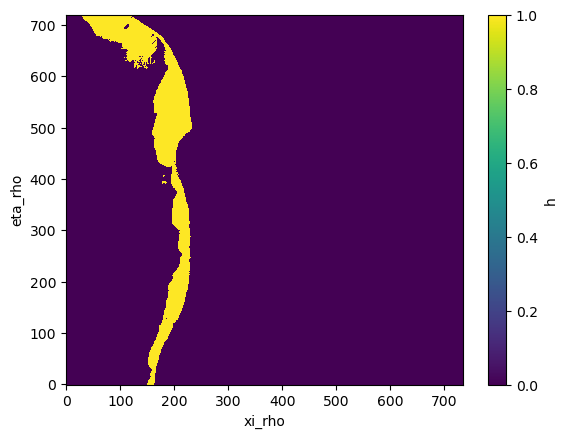

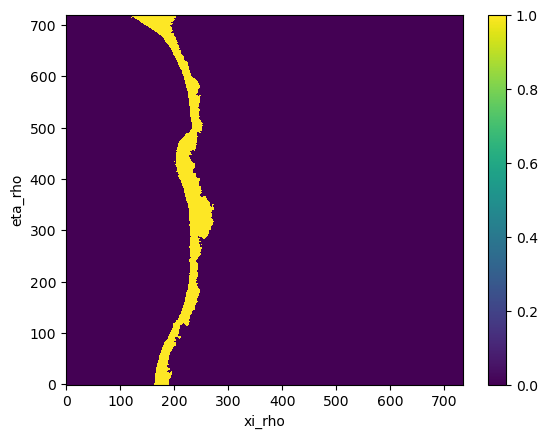

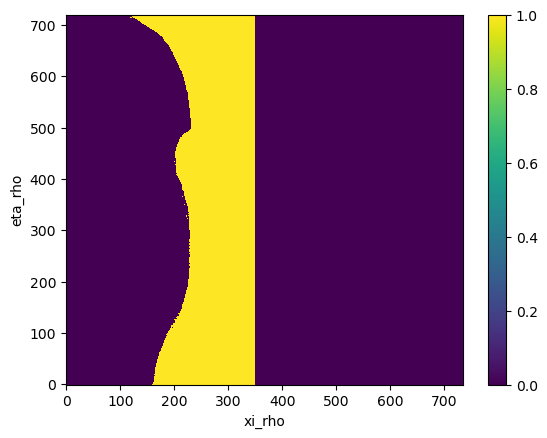

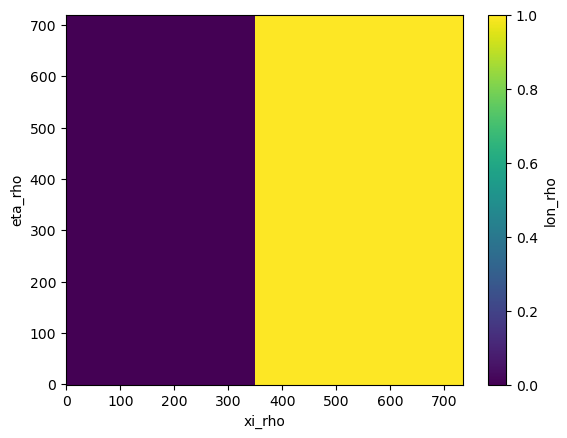

In [11]:
weights = ds.dA
weights.name = "weights"


# Shelf
mask_shelf = (ds.h<100) & (ds.h>20)

mask_shelf.plot()
plt.show()

#ds.temp.isel(s_rho=-1).where(mask_shelf).mean(dim='eta_rho').mean(dim='xi_rho').plot()
#ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')).plot()


# Slope
mask_slope = (ds.h>100) & (ds.h<1500) & (ds.lon_rho<154.3)

mask_slope.plot()
plt.show()

# EAC
mask_eac = (ds.h>90) & (ds.lon_rho<155)

mask_eac.plot()
plt.show()

# offshore
mask_offshore = (ds.lon_rho>155)

mask_offshore.plot()
plt.show()

# make masks for obs

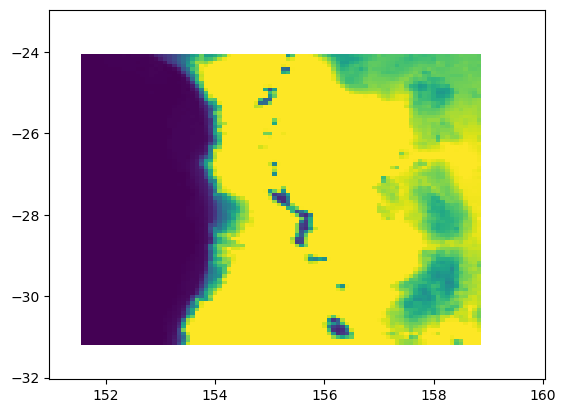

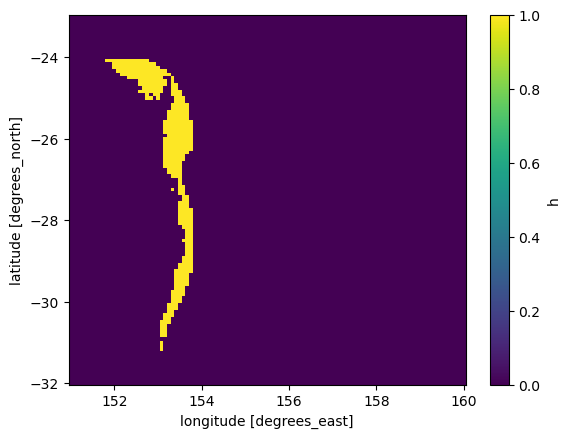

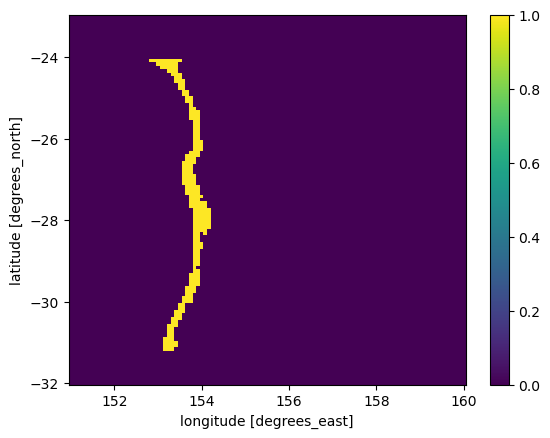

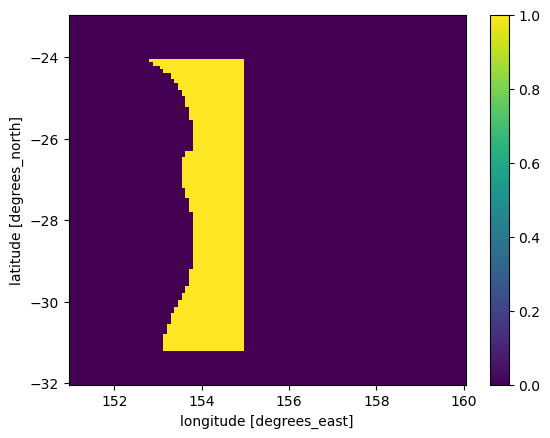

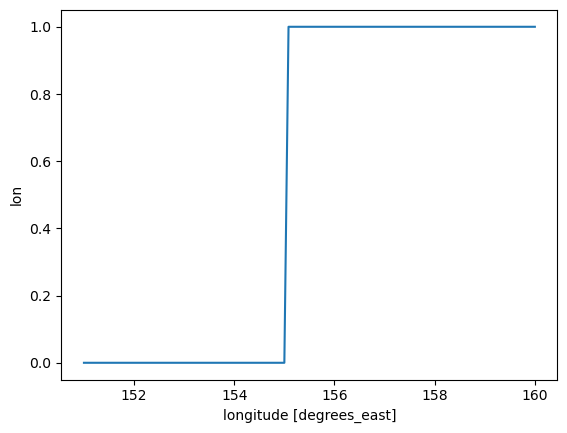

In [12]:
from scipy.interpolate import griddata


# flatten model grid
points = np.column_stack([
    ds.lon_rho.values.ravel(),
    ds.lat_rho.values.ravel()
])

values = ds.h.values.ravel()

# target grid
lon2d, lat2d = np.meshgrid(SST_ds.lon.values, SST_ds.lat.values)


# interpolate
h_interp = griddata(
    points,
    values,
    (lon2d, lat2d),
    method="linear"
)

plt.pcolormesh(SST_ds.lon,SST_ds.lat,h_interp)
plt.show()
plt.pcolormesh(ds.lon_rho,ds.lat_rho,ds.h)

SST_ds["h"] = (("lat", "lon"), h_interp)

# Shelf
mask_shelf_sst = (SST_ds.h<100) & (SST_ds.h>20)

mask_shelf_sst.plot()
plt.show()

#ds.temp.isel(s_rho=-1).where(mask_shelf).mean(dim='eta_rho').mean(dim='xi_rho').plot()
#ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')).plot()


# Slope
mask_slope_sst = (SST_ds.h>100) & (SST_ds.h<1500) & (SST_ds.lon<154.3)

mask_slope_sst.plot()
plt.show()

# EAC
mask_eac_sst = (SST_ds.h>90) & (SST_ds.lon<155)

mask_eac_sst.plot()
plt.show()

# offshore
mask_offshore_sst = (SST_ds.lon>155)

mask_offshore_sst.plot()
plt.show()



# Eval Plots 

Figure 4?:

Rows: SST, SSH, MKE

Columns: shelf | slope | EAC | offshore



CPU times: user 1.66 s, sys: 12 ms, total: 1.67 s
Wall time: 1.71 s


[Text(0, 17.5, ''),
 Text(0, 20.0, ''),
 Text(0, 22.5, ''),
 Text(0, 25.0, ''),
 Text(0, 27.5, ''),
 Text(0, 30.0, '')]

<Figure size 640x480 with 0 Axes>

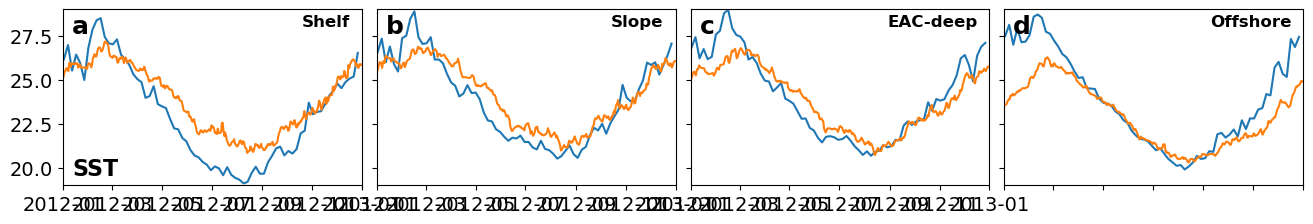

In [13]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.25)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[0,0])

ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_shelf_sst).mean(('lon','lat')))


ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'a', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.text(0.03, 0.16, 'SST', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')

##############################
# Slope
ax = fig.add_subplot(gs[0,1])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_slope_sst).mean(('lon','lat')))

ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'b', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')

##############################
# EAC
ax = fig.add_subplot(gs[0,2])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_eac_sst).mean(('lon','lat')))


ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'EAC-deep', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'c', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')

#############################
# Offshore
ax = fig.add_subplot(gs[0,3])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_offshore_sst).mean(('lon','lat')))

ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'd', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_xticklabels('')
ax.set_yticklabels('')


In [14]:
# now do SSH
SSH_ds

<xarray.Dataset>
Dimensions:    (TIME: 3288, LONGITUDE: 46, LATITUDE: 46)
Coordinates:
  * TIME       (TIME) datetime64[ns] 2012-01-01 2012-01-02 ... 2020-12-31
  * LONGITUDE  (LONGITUDE) float64 151.0 151.2 151.4 151.6 ... 159.6 159.8 160.0
  * LATITUDE   (LATITUDE) float64 -32.0 -31.8 -31.6 -31.4 ... -23.4 -23.2 -23.0
Data variables:
    GSLA       (TIME, LATITUDE, LONGITUDE) float64 ...
    GSL        (TIME, LATITUDE, LONGITUDE) float64 ...
    UCUR       (TIME, LATITUDE, LONGITUDE) float64 ...
    VCUR       (TIME, LATITUDE, LONGITUDE) float64 ...
    UCUR_MEAN  (TIME, LATITUDE, LONGITUDE) float64 ...
    VCUR_MEAN  (TIME, LATITUDE, LONGITUDE) float64 ...
    speed      (TIME, LATITUDE, LONGITUDE) float64 nan nan nan ... 0.1491 0.2057
Attributes: (12/35)
    author:                        Cahill, Madeleine
    author_email:                  madeleine.cahill@csiro.au
    citation:                      The citation in a list of references is: "...
    Conventions:                   CF-1.6,IMOS-1.4
    date_created:                  2022-07-16T01:34:51Z
    geospatial_lat_max:            -23.0
    ...                            ...
    data_centre_email:             info@aodn.org.au
    disclaimer:                    Data, products and services from IMOS are ...
    distribution_statement:        Data may be re-used, provided that related...
    license:                       http://creativecommons.org/licenses/by/4.0/
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         Gridded Sea Level Anomaly - Australia Regi...

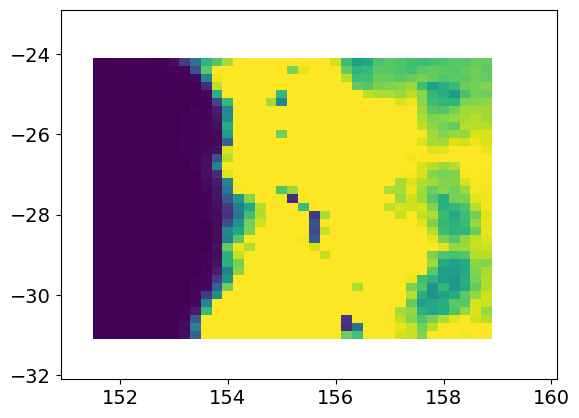

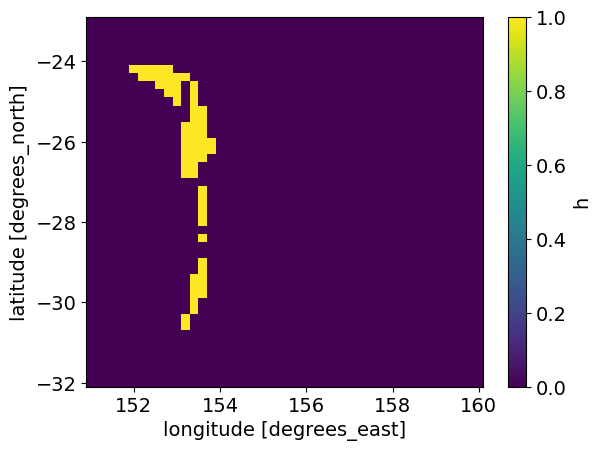

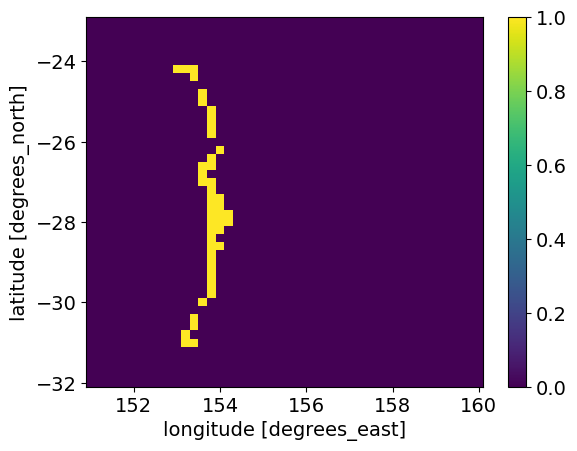

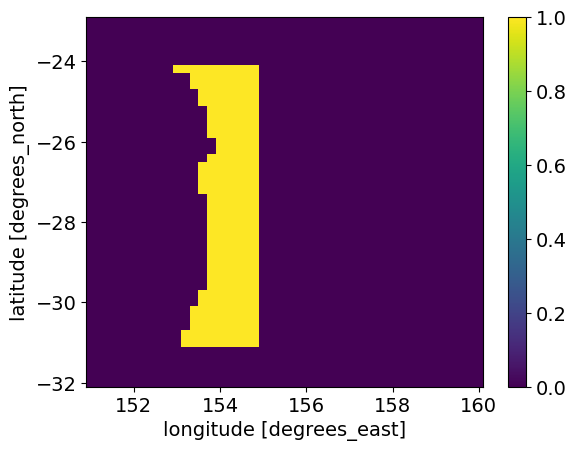

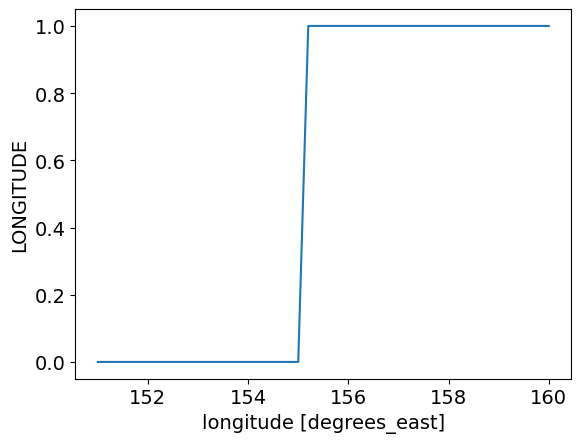

In [15]:
from scipy.interpolate import griddata


# flatten model grid
points = np.column_stack([
    ds.lon_rho.values.ravel(),
    ds.lat_rho.values.ravel()
])

values = ds.h.values.ravel()


# target grid
lon2d, lat2d = np.meshgrid(SSH_ds.LONGITUDE.values, SSH_ds.LATITUDE.values)


# interpolate
h_interp = griddata(
    points,
    values,
    (lon2d, lat2d),
    method="linear"
)

plt.pcolormesh(SSH_ds.LONGITUDE,SSH_ds.LATITUDE,h_interp)
plt.show()
plt.pcolormesh(ds.lon_rho,ds.lat_rho,ds.h)

SSH_ds["h"] = (("LATITUDE", "LONGITUDE"), h_interp)

# Shelf
mask_shelf_ssh = (SSH_ds.h<100) & (SSH_ds.h>20)

mask_shelf_ssh.plot()
plt.show()

#ds.temp.isel(s_rho=-1).where(mask_shelf).mean(dim='eta_rho').mean(dim='xi_rho').plot()
#ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')).plot()


# Slope
mask_slope_ssh = (SSH_ds.h>100) & (SSH_ds.h<1500) & (SSH_ds.LONGITUDE<154.3)

mask_slope_ssh.plot()
plt.show()

# EAC
mask_eac_ssh = (SSH_ds.h>90) & (SSH_ds.LONGITUDE<155)

mask_eac_ssh.plot()
plt.show()

# offshore
mask_offshore_ssh = (SSH_ds.LONGITUDE>155)

mask_offshore_ssh.plot()
plt.show()



CPU times: user 1.89 s, sys: 20.3 ms, total: 1.91 s
Wall time: 1.98 s


[Text(0, 0.0, ''),
 Text(0, 0.2, ''),
 Text(0, 0.4, ''),
 Text(0, 0.6000000000000001, ''),
 Text(0, 0.8, '')]

<Figure size 640x480 with 0 Axes>

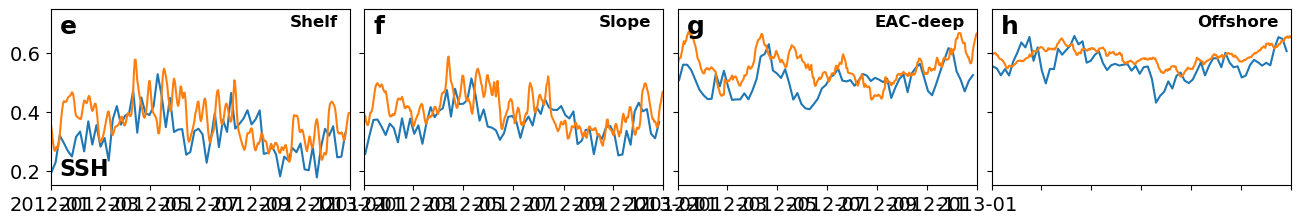

In [16]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.25)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[1,0])

ax.plot(times,ds.zeta.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'e', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.text(0.03, 0.16, 'SSH', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')

##############################
# Slope
ax = fig.add_subplot(gs[1,1])
ax.plot(times,ds.zeta.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'f', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')

##############################
# EAC
ax = fig.add_subplot(gs[1,2])
ax.plot(times,ds.zeta.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'EAC-deep', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'g', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')

#############################
# Offshore
ax = fig.add_subplot(gs[1,3])
ax.plot(times,ds.zeta.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'h', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_xticklabels('')
ax.set_yticklabels('')


# now kinetic energy

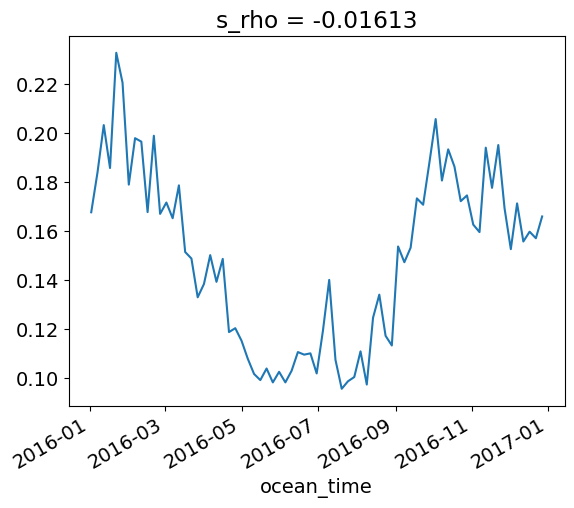

In [17]:
(0.5*(ds.u_eastward.isel(s_rho=-1)**2 + ds.v_northward.isel(s_rho=-1)**2)).weighted(weights).mean(('eta_rho','xi_rho')).plot()

In [18]:
# calculate ke's

ke = (0.5*(ds.u_eastward.isel(s_rho=-1)**2 + ds.v_northward.isel(s_rho=-1)**2))

ke_ssh = (0.5*(SSH_ds.UCUR.sel(TIME=slice('2011-12-01','2013-01-31'))**2 + SSH_ds.VCUR.sel(TIME=slice('2011-12-01','2013-01-31'))**2))

ke_ssh

<xarray.DataArray (TIME: 397, LATITUDE: 46, LONGITUDE: 46)>
array([[[       nan,        nan,        nan, ..., 0.07504336,
         0.10740665, 0.16775043],
        [       nan,        nan,        nan, ..., 0.0710858 ,
         0.07714786, 0.15114712],
        [       nan,        nan,        nan, ..., 0.0778129 ,
         0.04296776, 0.10443733],
        ...,
        [0.00042757, 0.00839698, 0.02140996, ..., 0.01130642,
         0.00682663, 0.01239101],
        [0.00571673, 0.00123972, 0.01084853, ..., 0.02156202,
         0.01507507, 0.00150163],
        [0.01478127, 0.02383502, 0.00937374, ..., 0.02734457,
         0.03624067, 0.0227786 ]],

       [[       nan,        nan,        nan, ..., 0.07497854,
         0.08455777, 0.14250878],
        [       nan,        nan,        nan, ..., 0.07554534,
         0.05967684, 0.12172272],
        [       nan,        nan,        nan, ..., 0.08969794,
         0.03864637, 0.08472758],
...
        [0.00310845, 0.00979992, 0.02087297, ..., 0.02370433,
         0.03703214, 0.05695826],
        [0.00547726, 0.0024742 , 0.00797029, ..., 0.03539769,
         0.03552442, 0.0381943 ],
        [0.01220591, 0.01533024, 0.00873503, ..., 0.04331192,
         0.0305039 , 0.02367831]],

       [[       nan,        nan,        nan, ..., 0.10982216,
         0.11354473, 0.06555343],
        [       nan,        nan,        nan, ..., 0.10182054,
         0.10033387, 0.05686033],
        [       nan,        nan,        nan, ..., 0.09295101,
         0.11236752, 0.09258931],
        ...,
        [0.00216698, 0.00894734, 0.01966091, ..., 0.02536319,
         0.03815341, 0.05832766],
        [0.00773349, 0.00097161, 0.00773928, ..., 0.03475271,
         0.03393614, 0.03644675],
        [0.01589845, 0.019956  , 0.0073497 , ..., 0.04106868,
         0.02825301, 0.02242603]]])
Coordinates:
  * TIME       (TIME) datetime64[ns] 2012-01-01 2012-01-02 ... 2013-01-31
  * LONGITUDE  (LONGITUDE) float64 151.0 151.2 151.4 151.6 ... 159.6 159.8 160.0
  * LATITUDE   (LATITUDE) float64 -32.0 -31.8 -31.6 -31.4 ... -23.4 -23.2 -23.0

In [19]:
SSH_ds.TIME

<xarray.DataArray 'TIME' (TIME: 3288)>
array(['2012-01-01T00:00:00.000000000', '2012-01-02T00:00:00.000000000',
       '2012-01-03T00:00:00.000000000', ..., '2020-12-29T00:00:00.000000000',
       '2020-12-30T00:00:00.000000000', '2020-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * TIME     (TIME) datetime64[ns] 2012-01-01 2012-01-02 ... 2020-12-31
Attributes:
    axis:           T
    long_name:      analysis time
    standard_name:  time
    valid_max:      90000.0
    valid_min:      0.0

CPU times: user 1.11 s, sys: 4.88 ms, total: 1.11 s
Wall time: 1.11 s


<Figure size 640x480 with 0 Axes>

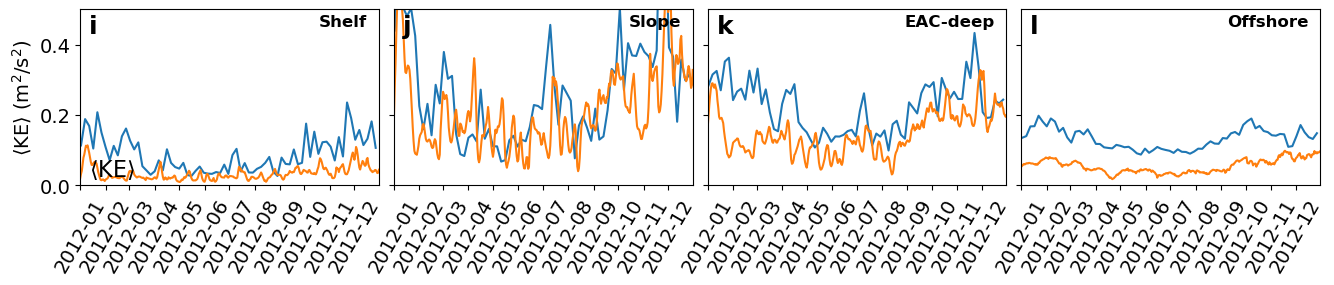

In [20]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.25)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[2,0])

ax.plot(times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
ax.set(ylabel = r"$\langle \mathrm{KE} \rangle$ (m$^2$/s$^2$)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'i', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.text(0.03, 0.16, r'$\langle \mathrm{KE} \rangle$', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
ax.tick_params(axis='x', labelrotation=60)
##############################
# Slope
ax = fig.add_subplot(gs[2,1])
ax.plot(times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'j', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
##############################
# EAC
ax = fig.add_subplot(gs[2,2])
ax.plot(times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'EAC-deep', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'k', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
#############################
# Offshore
ax = fig.add_subplot(gs[2,3])
ax.plot(times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'l', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)

In [21]:
import numpy as np

def datetime_to_float_ns(t):
    return t.astype("datetime64[ns]").astype("int64").astype(float)


def rmse_on_common_time(
    ts1, t1,
    ts2, t2,
    target_time,
    return_interpolated=False
):
    """
    Interpolate two time series onto a common time vector and compute RMSE.

    Parameters
    ----------
    return_interpolated : bool
        If True, also return interpolated ts1, ts2, and time vector.
    """

    t1n = datetime_to_float_ns(t1)
    t2n = datetime_to_float_ns(t2)
    ttn = datetime_to_float_ns(target_time)

    # Overlapping window
    tmin = max(t1n.min(), t2n.min())
    tmax = min(t1n.max(), t2n.max())

    overlap = (ttn >= tmin) & (ttn <= tmax)
    if not np.any(overlap):
        raise ValueError("No overlapping time period between datasets.")

    ttn = ttn[overlap]

    # Interpolate
    ts1i = np.interp(ttn, t1n, ts1)
    ts2i = np.interp(ttn, t2n, ts2)

    rmse = np.sqrt(np.mean((ts1i - ts2i)**2))

    if return_interpolated:
        # Convert numeric time back to datetime64[ns]
        t_interp = ttn.astype("int64").astype("datetime64[ns]")
        return rmse, ts1i, ts2i, t_interp

    return rmse


In [22]:
target_time = np.arange(
    np.datetime64("2012-01-01"),
    np.datetime64("2013-01-01"),
    np.timedelta64(1, "D")
).astype("datetime64[ns]")

rmse_shelf_ke = rmse_on_common_time(
    ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')), times,
    ke_ssh.sel(TIME=slice('2012-01-01','2013-01-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')),   SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-31')),
    target_time
)

rmse_slope_ke = rmse_on_common_time(
    ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')), times,
    ke_ssh.sel(TIME=slice('2012-01-01','2013-01-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')),   SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-31')),
    target_time
)


rmse_eac_ke = rmse_on_common_time(
    ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')), times,
    ke_ssh.sel(TIME=slice('2012-01-01','2013-01-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')),   SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-31')),
    target_time
)

rmse_offshore_ke = rmse_on_common_time(
    ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')), times,
    ke_ssh.sel(TIME=slice('2012-01-01','2013-01-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),   SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-31')),
    target_time
)


print(rmse_shelf_ke)
print(rmse_slope_ke)
print(rmse_eac_ke)
print(rmse_offshore_ke)


0.06716903630173311
0.1400746581408189
0.10007026958476843
0.08044914289290088


In [23]:
def annotate_rmse(
    ax,
    t1, ts1,
    t2, ts2,
    target_time,
    label=r'$\langle \mathrm{KE} \rangle$',
    xy=(0.03, 0.1),
    fontsize=12,
    return_interpolated=False
):
    out = rmse_on_common_time(
        ts1, t1,
        ts2, t2,
        target_time,
        return_interpolated=return_interpolated
    )

    if return_interpolated:
        rmse, ts1i, ts2i, t_interp = out
    else:
        rmse = out

    ax.text(
        xy[0], xy[1],
        rf'{label} = {rmse:.3f}',
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight='bold',
        va='top'
    )

    if return_interpolated:
        return rmse, ts1i, ts2i, t_interp

    return rmse


CPU times: user 1.72 s, sys: 2.45 ms, total: 1.72 s
Wall time: 1.72 s


<Figure size 640x480 with 0 Axes>

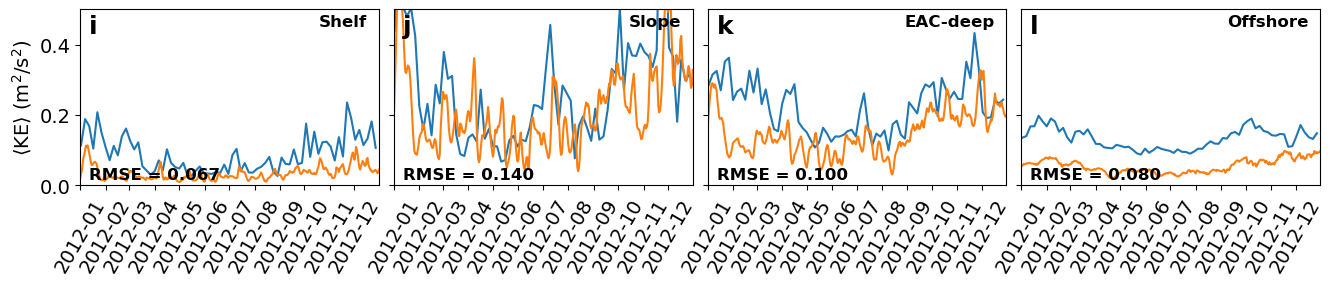

In [24]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.25)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[2,0])

ax.plot(times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
ax.set(ylabel = r"$\langle \mathrm{KE} \rangle$ (m$^2$/s$^2$)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'i', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
# ax.text(0.03, 0.16, r'$\langle \mathrm{KE} \rangle$', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
##############################
# Slope
ax = fig.add_subplot(gs[2,1])
ax.plot(times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'j', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
##############################
# EAC
ax = fig.add_subplot(gs[2,2])
ax.plot(times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'EAC-deep', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'k', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
#############################
# Offshore
ax = fig.add_subplot(gs[2,3])
ax.plot(times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'l', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')

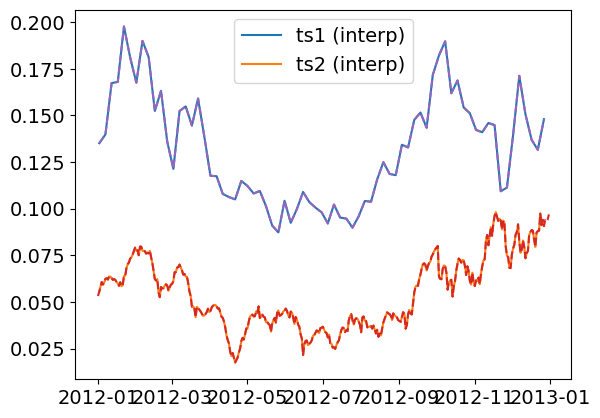

0.08044914289290088


In [25]:
rmse, ts1i, ts2i, t_interp = rmse_on_common_time(
    ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),times,
                     ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),
    target_time,
    return_interpolated=True
)

plt.plot(t_interp, ts1i, label='ts1 (interp)')
plt.plot(times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),'C4',linestyle='--')
plt.plot(t_interp, ts2i, label='ts2 (interp)')
plt.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),'C3',linestyle='--')
plt.legend()
plt.show()

print(np.sqrt(np.mean((ts1i-ts2i)**2)))

# now bring together

In [36]:
import matplotlib.dates as mdates


CPU times: user 5.14 s, sys: 4.4 ms, total: 5.15 s
Wall time: 5.15 s


<Figure size 640x480 with 0 Axes>

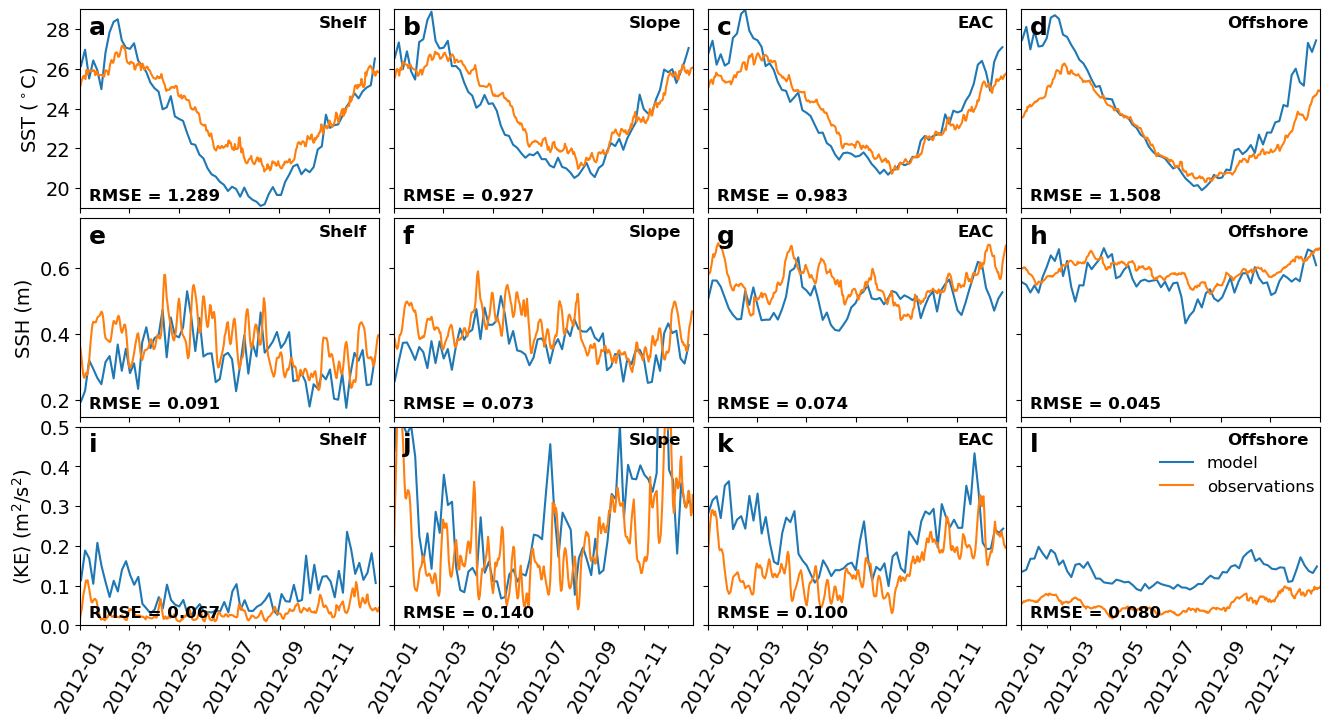

In [56]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.05)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[0,0])

ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_shelf_sst).mean(('lon','lat')))


ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'a', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
# ax.text(0.03, 0.16, 'SST', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')),
                     SST_ds.time.sel(time=slice('2012-01-01','2012-12-31')),SST_ds.sst.sel(time=slice('2012-01-01','2012-12-31')).where(mask_shelf_sst).mean(('lon','lat')),
                     target_time,label=r'RMSE')
ax.set(ylabel = r"SST ($^\circ$C)")

##############################
# Slope
ax = fig.add_subplot(gs[0,1])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_slope_sst).mean(('lon','lat')))

ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'b', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.temp.isel(s_rho=-1).where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')),
                     SST_ds.time.sel(time=slice('2012-01-01','2012-12-31')),SST_ds.sst.sel(time=slice('2012-01-01','2012-12-31')).where(mask_slope_sst).mean(('lon','lat')),
                     target_time,label=r'RMSE')
##############################
# EAC
ax = fig.add_subplot(gs[0,2])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_eac_sst).mean(('lon','lat')))


ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'EAC', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'c', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.temp.isel(s_rho=-1).where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')),
                     SST_ds.time.sel(time=slice('2012-01-01','2012-12-31')),SST_ds.sst.sel(time=slice('2012-01-01','2012-12-31')).where(mask_eac_sst).mean(('lon','lat')),
                     target_time,label=r'RMSE')
#############################
# Offshore
ax = fig.add_subplot(gs[0,3])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_offshore_sst).mean(('lon','lat')))

ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'd', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_xticklabels('')
ax.set_yticklabels('')
rmse = annotate_rmse(ax,times,ds.temp.isel(s_rho=-1).where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),
                     SST_ds.time.sel(time=slice('2012-01-01','2012-12-31')),SST_ds.sst.sel(time=slice('2012-01-01','2012-12-31')).where(mask_offshore_sst).mean(('lon','lat')),
                     target_time,label=r'RMSE')

##############  SSH

# Shelf
ax = fig.add_subplot(gs[1,0])

ax.plot(times,ds.zeta.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'e', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
# ax.text(0.03, 0.16, 'SSH', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
rmse = annotate_rmse(ax,times,ds.zeta.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
ax.set_xticklabels('')
ax.set(ylabel = r"SSH (m)")

##############################
# Slope
ax = fig.add_subplot(gs[1,1])
ax.plot(times,ds.zeta.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'f', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.zeta.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
##############################
# EAC
ax = fig.add_subplot(gs[1,2])
ax.plot(times,ds.zeta.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'EAC', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'g', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.zeta.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
#############################
# Offshore
ax = fig.add_subplot(gs[1,3])
ax.plot(times,ds.zeta.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'h', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_xticklabels('')
ax.set_yticklabels('')
rmse = annotate_rmse(ax,times,ds.zeta.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')


#################   KE  #######################

# Shelf
ax = fig.add_subplot(gs[2,0])

ax.plot(times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
ax.set(ylabel = r"$\langle \mathrm{KE} \rangle$ (m$^2$/s$^2$)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'i', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
# ax.text(0.03, 0.16, r'$\langle \mathrm{KE} \rangle$', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
##############################
# Slope
ax = fig.add_subplot(gs[2,1])
ax.plot(times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'j', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
##############################
# EAC
ax = fig.add_subplot(gs[2,2])
ax.plot(times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'EAC', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'k', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
#############################
# Offshore
ax = fig.add_subplot(gs[2,3])
ax.plot(times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),label='model')

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),label='observations')

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'l', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.legend(frameon=False,fontsize=12,bbox_to_anchor=(1.03, 0.93))